# VibeShift — RTX 4090 Training
Flow-matching genre transformation · **tqdm** progress bars · **W&B** experiment tracking

| Step | Cell |
|---|---|
| 1 | Install deps |
| 2 | Imports + GPU check |
| 3 | Config (edit paths here) |
| 4 | W&B login |
| 5 | Data loaders |
| 6 | Build model |
| 7 | Optimizer + scheduler |
| 8 | **Train** |
| 9 | Plot results |
| 10 | Gradient norms |
| 11 | Quick inference test |

In [ ]:
# Cell 1 — Install deps (run once, then restart kernel)
%pip install -q wandb tqdm

In [ ]:
import subprocess
subprocess.run(["pip", "install", "--upgrade", "wandb"], check=True)

In [1]:
import os
os.environ["WANDB_API_KEY"] = "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"
os.environ["WANDB_NOTEBOOK_NAME"] = "train_vibeshift_4090"

In [ ]:
# Cell 2 — Imports + GPU check
import sys, os

# Resolve workspace root (works from notebooks/training/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import wandb
from tqdm.auto import tqdm

from models.dit import DiT
from models.flow import FlowMatching
from training import Trainer, TrainingConfig
from dataloader import create_dataloader

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {props.total_memory / 1e9:.1f} GB")
    print(f"BF16    : {torch.cuda.is_bf16_supported()}")

film_conditioner.py STARTED
PyTorch : 2.10.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4090
VRAM    : 25.3 GB
BF16    : True


## ⚙️ Config
Edit **PATHS** and **MODEL_CONFIG** here. Hyperparameter defaults are already tuned for RTX 4090 (24 GB).

In [3]:
# Cell 3 — Config

SOURCE_DIR     = r"/workspace/vibe/source_latents"
TARGET_DIR     = r"/workspace/vibe/target_latents"  # was: classical_dac
CHECKPOINT_DIR = r"/workspace/vibe/checkpoints_fixed"
LOG_DIR        = r"/workspace/vibe/checkpoints_fixed/logs"
RUN_NAME       = "synth-to-punk-4090"

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

os.makedirs(LOG_DIR, exist_ok=True)

MODEL_CONFIG = dict(
    input_dim  = 768,
    embed_dim  = 512,
    num_blocks = 8,
    num_heads  = 8,
    num_genres = 3,
    hidden_dim = 2048,
    dropout    = 0.1,
)

GENRE_SOURCE = 0  # synth/MIDI
GENRE_TARGET = 1  # punk

config = TrainingConfig(
    num_epochs             = 200,
    batch_size             = 16,
    learning_rate          = 1e-3,      
    weight_decay           = 0.01,
    gradient_clip          = 1.0,
    accumulation_steps     = 1,
    early_stopping_patience= 20,
    monitor_gradients      = True,
    use_amp                = True,
    device                 = "cuda" if torch.cuda.is_available() else "cpu",
    wandb_project          = "vibeshift",
    wandb_run_name         = RUN_NAME,
    num_workers            = 4,         # was: 8 — Vast.ai deadlock risk with 8
    pin_memory             = True,
)

## 📊 W&B Login

In [4]:
# Cell 4 — W&B login
# Opens a browser prompt or uses WANDB_API_KEY env var silently
wandb.login()

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find train_vibeshift_4090.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: dhanujanarada (dhanujanarada-informatics-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 📂 Data

In [5]:

# Cell 5a — Dataset split

from torch.utils.data import Subset
from dataloader import GenreAwareLatentDataset

# Build genre label dict — every sample is labelled as source genre (synth=0)
# The model learns to map synth latents → punk latents via flow matching
_base = GenreAwareLatentDataset(
    source_dir   = SOURCE_DIR,
    target_dir   = TARGET_DIR,
    genre_labels = None,
)
genre_label_dict = {i: GENRE_SOURCE for i in range(len(_base))}

full_dataset = GenreAwareLatentDataset(
    source_dir   = SOURCE_DIR,
    target_dir   = TARGET_DIR,
    genre_labels = genre_label_dict,
)

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_set = Subset(full_dataset, range(0, n_train))
val_set   = Subset(full_dataset, range(n_train, n_train + n_val))
test_set  = Subset(full_dataset, range(n_train + n_val, n_total))

print(f"Total : {n_total}")
print(f"Train : {len(train_set)}")
print(f"Val   : {len(val_set)}")
print(f"Test  : {len(test_set)}")


Dataset initialized with 28496 samples (lazy loading)
  Source dir: /workspace/vibe/source_latents
  Target dir: /workspace/vibe/target_latents
Dataset initialized with 28496 samples (lazy loading)
  Source dir: /workspace/vibe/source_latents
  Target dir: /workspace/vibe/target_latents
Total : 28496
Train : 22796
Val   : 2849
Test  : 2851


In [6]:

# Cell 5b — DataLoaders
info = _base.get_info()

from torch.utils.data import DataLoader
from dataloader import default_collate_with_dynamic_padding

def make_loader(subset, shuffle: bool, drop_last: bool) -> DataLoader:
    return DataLoader(
        subset,
        batch_size         = config.batch_size,
        shuffle            = shuffle,
        num_workers        = config.num_workers,
        pin_memory         = config.pin_memory,
        drop_last          = drop_last,
        persistent_workers = config.num_workers > 0,  # added
        collate_fn         = default_collate_with_dynamic_padding,
    )

train_loader = make_loader(train_set, shuffle=True,  drop_last=True)
val_loader   = make_loader(val_set,   shuffle=False, drop_last=False)
test_loader  = make_loader(test_set,  shuffle=False, drop_last=False)

info = full_dataset.get_info()
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Embedding dim : {info['embedding_dim']}")

MODEL_CONFIG["input_dim"] = info["embedding_dim"]


Computing dataset max sequence length...
Computing dataset max sequence length...
Train batches : 1424
Val   batches : 179
Embedding dim : 768


## 🏗️ Model

In [7]:
# Cell 6 — Build model
dit   = DiT(**MODEL_CONFIG)
model = FlowMatching(dit)

# Optional: torch.compile gives ~15–30% speedup on 4090 (PyTorch 2+)
# model = torch.compile(model)

n_total    = sum(p.numel() for p in model.parameters())
n_trainable= sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters : {n_total/1e6:.2f}M total  {n_trainable/1e6:.2f}M trainable")
print(f"Model cfg  : {MODEL_CONFIG}")

# Quick VRAM estimate (rough: 4 bytes * params * 4 for optimizer states)
vram_est_gb = (n_trainable * 4 * 4) / 1e9
print(f"Rough VRAM est (model+optim): {vram_est_gb:.1f} GB")

Parameters : 36.51M total  36.51M trainable
Model cfg  : {'input_dim': 768, 'embed_dim': 512, 'num_blocks': 8, 'num_heads': 8, 'num_genres': 3, 'hidden_dim': 2048, 'dropout': 0.1}
Rough VRAM est (model+optim): 0.6 GB


## 🔧 Optimizer & Scheduler
Using **AdamW** with β₂=0.95 (good for transformers) + **10-epoch linear warmup** → **cosine decay**.

/venv/main/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


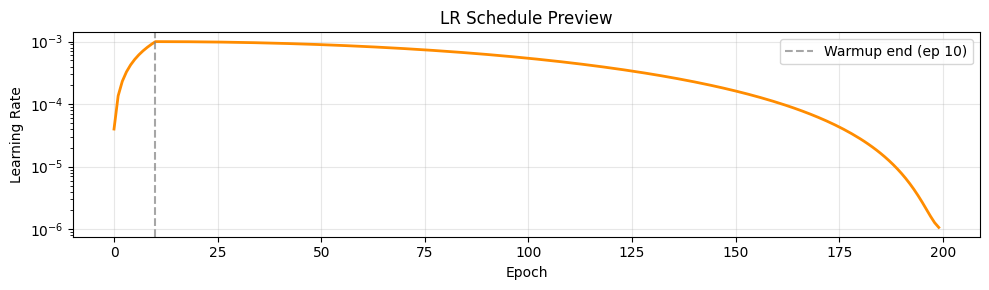

Peak LR  : 1.00e-03
Start LR : 4.00e-05
Final LR : 1e-6


In [8]:
# Cell 7 — Optimizer + scheduler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = config.learning_rate,
    weight_decay = config.weight_decay,
    betas        = (0.9, 0.95),
)

WARMUP_EPOCHS = 10
COSINE_EPOCHS = config.num_epochs - WARMUP_EPOCHS

warmup_sched = LinearLR(
    optimizer,
    start_factor = 1 / 25,  # initial_lr = peak_lr / 25
    end_factor   = 1.0,
    total_iters  = WARMUP_EPOCHS,
)
cosine_sched = CosineAnnealingLR(
    optimizer,
    T_max   = COSINE_EPOCHS,
    eta_min = 1e-6,
)
scheduler = SequentialLR(
    optimizer,
    schedulers = [warmup_sched, cosine_sched],
    milestones = [WARMUP_EPOCHS],
)

# Preview LR curve
_lrs = []
_opt_preview = torch.optim.AdamW([torch.zeros(1)], lr=config.learning_rate)
_w = LinearLR(_opt_preview, 1/25, 1.0, WARMUP_EPOCHS)
_c = CosineAnnealingLR(_opt_preview, COSINE_EPOCHS, 1e-6)
_s = SequentialLR(_opt_preview, [_w, _c], [WARMUP_EPOCHS])
for _ in range(config.num_epochs):
    _lrs.append(_opt_preview.param_groups[0]["lr"])
    _s.step()

plt.figure(figsize=(10, 3))
plt.plot(_lrs, linewidth=2, color='darkorange')
plt.axvline(WARMUP_EPOCHS, linestyle='--', color='gray', alpha=0.7, label=f'Warmup end (ep {WARMUP_EPOCHS})')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('LR Schedule Preview')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak LR  : {config.learning_rate:.2e}")
print(f"Start LR : {config.learning_rate/25:.2e}")
print(f"Final LR : 1e-6")

In [14]:
# Cell 8b — List all saved checkpoints
import pathlib

ckpt_dir = pathlib.Path(CHECKPOINT_DIR) / RUN_NAME

if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.glob("*.pt"))
    if ckpts:
        print(f"Found {len(ckpts)} checkpoint(s) in {ckpt_dir}:\n")
        for ck in ckpts:
            size_mb = ck.stat().st_size / 1e6
            meta = torch.load(ck, map_location="cpu")
            saved_epoch = meta.get("epoch", "?")
            saved_loss  = meta.get("best_loss", float("inf"))
            print(f"  {ck.name:<45} epoch={saved_epoch:<5} best_loss={saved_loss:.6f}  ({size_mb:.1f} MB)")
    else:
        print(f"No checkpoints found in {ckpt_dir}")
else:
    print(f"Directory not found: {ckpt_dir} — run Cell 8 first")

Found 13 checkpoint(s) in /workspace/vibe/checkpoints_fixed/synth-to-punk-4090:

  best.pt                                       epoch=103   best_loss=3.144005  (439.6 MB)
  checkpoint_epoch_100_epoch_30.pt              epoch=100   best_loss=3.440119  (439.6 MB)
  checkpoint_epoch_10_epoch_10.pt               epoch=10    best_loss=34.587443  (438.5 MB)
  checkpoint_epoch_110_epoch_40.pt              epoch=110   best_loss=3.144005  (439.7 MB)
  checkpoint_epoch_120_epoch_50.pt              epoch=120   best_loss=3.144005  (439.9 MB)
  checkpoint_epoch_20_epoch_20.pt               epoch=20    best_loss=18.513821  (438.6 MB)
  checkpoint_epoch_30_epoch_30.pt               epoch=30    best_loss=10.842289  (438.7 MB)
  checkpoint_epoch_40_epoch_40.pt               epoch=40    best_loss=10.292602  (438.8 MB)
  checkpoint_epoch_50_epoch_50.pt               epoch=50    best_loss=10.114973  (439.0 MB)
  checkpoint_epoch_60_epoch_60.pt               epoch=60    best_loss=8.342382  (439.1 MB)
  ch

In [13]:
# Cell 8c — Resume training from a specific epoch
# ── EDIT THIS ──────────────────────────────────
RESUME_FROM_EPOCH = 70  # <-- change to whichever epoch you want
# ───────────────────────────────────────────────
import pathlib

resume_ckpt = pathlib.Path(CHECKPOINT_DIR) / RUN_NAME / f"checkpoint_epoch_{RESUME_FROM_EPOCH}_epoch_{RESUME_FROM_EPOCH}.pt"

if not resume_ckpt.exists():
    raise FileNotFoundError(
        f"Not found: {resume_ckpt}\n"
        f"Run Cell 8b to see available checkpoints."
    )

# Rebuild trainer (model + optimizer must exist from Cells 6 & 7)
trainer = Trainer(
    model          = model,
    optimizer      = optimizer,
    device         = config.device,
    checkpoint_dir = CHECKPOINT_DIR,
    name           = RUN_NAME,
    use_amp        = config.use_amp,
    wandb_project  = config.wandb_project,
    wandb_run_name = config.wandb_run_name + f"_resume_ep{RESUME_FROM_EPOCH}",
    wandb_config   = {**config.to_dict(), **MODEL_CONFIG, "resumed_from_epoch": RESUME_FROM_EPOCH},
)

# load_optimizer=True — restores momentum + scheduler position
# so LR continues from where it left off, not from warmup start
resumed_epoch = trainer.load_checkpoint(str(resume_ckpt), load_optimizer=True)

remaining_epochs = config.num_epochs - resumed_epoch
print(f"\nResuming from epoch {resumed_epoch} → {remaining_epochs} epochs remaining")

def loss_fn(x0, x1, genre_ids, mask=None):
    return model.compute_loss(x0, x1, genre_ids, mask)

results = trainer.train(
    train_dataloader        = train_loader,
    num_epochs              = remaining_epochs,
    loss_fn                 = loss_fn,
    val_dataloader          = val_loader,
    scheduler               = scheduler,
    gradient_clip           = config.gradient_clip,
    accumulation_steps      = config.accumulation_steps,
    early_stopping_patience = config.early_stopping_patience,
    log_interval            = config.log_interval,
    monitor_gradients       = config.monitor_gradients,
    save_interval           = 10,
)

/workspace/vibe/training.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


AMP enabled


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Trainer initialized for 'synth-to-punk-4090'
  Device: cuda
  Checkpoint dir: /workspace/vibe/checkpoints_fixed/synth-to-punk-4090
  W&B run: https://wandb.ai/dhanujanarada-informatics-institute-of-technology/vibeshift/runs/id7042zz
Checkpoint loaded from /workspace/vibe/checkpoints_fixed/synth-to-punk-4090/checkpoint_epoch_70_epoch_70.pt
  Resuming from epoch 70
  Best loss so far: 7.749089

Resuming from epoch 70 → 130 epochs remaining

Training 'synth-to-punk-4090' for 130 epochs
  Accumulation steps: 1
  AMP: Enabled


Ep 71:   0%|          | 0/1424 [00:00<?, ?it/s]

...

Epoch  52/130 | Train Loss: 6.739981 | Val Loss: 11.257579 | LR: 8.84e-04 | Grad Norm: 1.0000 | Best: 3.144005 (ep 33)


Ep 123:   0%|          | 0/1424 [00:00<?, ?it/s]

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  53/130 | Train Loss: 7.020402 | Val Loss: 5.934876 | LR: 8.79e-04 | Grad Norm: 1.0000 | Best: 3.144005 (ep 33)

Early stopping at epoch 53
Best validation loss: 3.144005 (epoch 33)

Training Complete

Loss Statistics:
  Initial loss: 1784.00284448
  Final loss:   7.02040223
  Best loss:    3.14400467 (epoch 33)
  Improvement:  99.61%

Validation Statistics:
  Best val loss: 3.14400467

Gradient Statistics:
  Average gradient norm: nan
  Min gradient norm:     nan
  Max gradient norm:     nan



batch/grad_norm,▅▅▄▄█▅▅▅▄▄▄▅▂▂▅▅▄▂▄▄▂▄▁▄▂▄▅▅▂▅▂▅▅▅▅█▂▂▂▅
batch/loss,▁▂▅▅▃▂▂█▁▁▅▂▁▁▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▂▁▁▁▁▁▁
batch/lr,▂▂▄▅▅▇▇▇██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch/best_loss,██████████▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/grad_norm_mean,██ ██ ▁▁ ▁▁ ▁ ▁▁ ▁▁ ▁ ▁ ▁ ▁▁ ▁ ▁
epoch/lr,▂▃▃▄▅▆▇█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/train_loss,▂▄▅▆▇██▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_loss,▂▄▅▅▆██▇▂▁▁▁▂▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
batch/grad_norm,1.0


In [ ]:
# Cell 8d — Load best.pt for inference only (no training)
# Run this instead of Cell 8c when training is done
# and you just want to run Cell 11 (inference)
import pathlib

best_ckpt = pathlib.Path(CHECKPOINT_DIR) / RUN_NAME / "best.pt"

if not best_ckpt.exists():
    raise FileNotFoundError(
        f"best.pt not found: {best_ckpt}\n"
        f"Run Cell 8b to check what's available."
    )

# load_optimizer=False — weights only, no optimizer state needed for inference
trainer.load_checkpoint(str(best_ckpt), load_optimizer=False)
model.eval()

print("best.pt loaded — model in eval() mode, ready for Cell 11")
```

---

**Visual summary of where things go:**
```
Cell 15  →  Cell 8  (Train — run fresh)
Cell 8b  →  List checkpoints
Cell 8c  →  Resume from epoch N      ← run this INSTEAD of Cell 8 if job died
Cell 8d  →  Load best for inference  ← run this INSTEAD of Cell 8 if just inferring
Cell 16  →  Loss Curves (unchanged)

## 🚀 Train
Progress bars via **tqdm** · metrics streamed live to **[W&B](https://wandb.ai)**.

In [ ]:
# Cell 8 — Train
trainer = Trainer(
    model          = model,
    optimizer      = optimizer,
    device         = config.device,
    checkpoint_dir = CHECKPOINT_DIR,
    name           = RUN_NAME,
    use_amp        = config.use_amp,
    wandb_project  = config.wandb_project,
    wandb_run_name = config.wandb_run_name,
    wandb_config   = {**config.to_dict(), **MODEL_CONFIG},
)

def loss_fn(x0, x1, genre_ids, mask=None):
    return model.compute_loss(x0, x1, genre_ids, mask)

results = trainer.train(
    train_dataloader        = train_loader,
    num_epochs              = config.num_epochs,
    loss_fn                 = loss_fn,
    val_dataloader          = val_loader,
    scheduler               = scheduler,
    gradient_clip           = config.gradient_clip,
    accumulation_steps      = config.accumulation_steps,
    early_stopping_patience = config.early_stopping_patience,
    log_interval            = config.log_interval,
    monitor_gradients       = config.monitor_gradients,
    save_interval           = 10,
)

/workspace/vibe/training.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


AMP enabled


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Trainer initialized for 'synth-to-punk-4090'
  Device: cuda
  Checkpoint dir: /workspace/vibe/checkpoints_fixed/synth-to-punk-4090
  W&B run: https://wandb.ai/dhanujanarada-informatics-institute-of-technology/vibeshift/runs/ict6kpu2

Training 'synth-to-punk-4090' for 200 epochs
  Accumulation steps: 1
  AMP: Enabled


Ep 1:   0%|          | 0/1424 [00:00<?, ?it/s]

...

Ep 67:   0%|          | 0/1424 [00:00<?, ?it/s]

Epoch  67/200 | Train Loss: 10.245864 | Val Loss: 9.351251 | LR: 7.94e-04 | Grad Norm: 1.0000 | Best: 7.749089 (ep 65)


Ep 68:   0%|          | 0/1424 [00:00<?, ?it/s]

Epoch  68/200 | Train Loss: 10.175327 | Val Loss: 11.052078 | LR: 7.87e-04 | Grad Norm: 1.0000 | Best: 7.749089 (ep 65)


Ep 69:   0%|          | 0/1424 [00:00<?, ?it/s]

## 📈 Loss Curves

In [ ]:
# Cell 9 — Plot training results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"VibeShift — {RUN_NAME}", fontsize=14, fontweight="bold")

# Loss curves
ax = axes[0]
ax.plot(results["epoch_losses"], label="Train", linewidth=2, color="royalblue")
if results["val_losses"]:
    ax.plot(results["val_losses"], label="Val", linewidth=2, color="tomato")
ax.axvline(
    results["best_epoch"], linestyle="--", color="green", alpha=0.7,
    label=f"Best (ep {results['best_epoch']+1})\n{results['best_loss']:.6f}"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Epoch Loss")
ax.legend(fontsize=8)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# LR schedule
ax = axes[1]
ax.plot(results["learning_rates"], linewidth=2, color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule (actual)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# Batch loss (smoothed)
ax = axes[2]
bl = results["batch_losses"]
if len(bl) >= 50:
    smoothed = np.convolve(bl, np.ones(50) / 50, mode="valid")
    ax.plot(bl, alpha=0.15, color="steelblue", linewidth=0.5)
    ax.plot(range(49, len(bl)), smoothed, color="steelblue", linewidth=2, label="50-step MA")
else:
    ax.plot(bl, color="steelblue", linewidth=1.5)
ax.set_xlabel("Batch")
ax.set_ylabel("Loss")
ax.set_title("Batch Loss")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
out_path = os.path.join(LOG_DIR, f"{RUN_NAME}_curves.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")
print(f"Best loss  : {results['best_loss']:.6f} @ epoch {results['best_epoch']+1}")
print(f"Final loss : {results['epoch_losses'][-1]:.6f}")

## 🔍 Gradient Norms

In [ ]:
# Cell 10 — Gradient norm analysis
norms = results["gradient_norms"]
if norms:
    plt.figure(figsize=(12, 4))
    window = min(50, len(norms) // 5)
    if len(norms) >= window:
        smoothed = np.convolve(norms, np.ones(window) / window, mode="valid")
        plt.plot(norms, alpha=0.2, color="purple", linewidth=0.5)
        plt.plot(range(window - 1, len(norms)), smoothed, color="purple", linewidth=2, label=f"{window}-step MA")
    else:
        plt.plot(norms, color="purple", linewidth=1.5)
    plt.axhline(
        config.gradient_clip, linestyle="--", color="red", alpha=0.7,
        label=f"Clip threshold ({config.gradient_clip})"
    )
    plt.xlabel("Optimizer Step")
    plt.ylabel("Gradient Norm (L2)")
    plt.title("Gradient Norm During Training")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Mean : {np.mean(norms):.4f}")
    print(f"Max  : {np.max(norms):.4f}")
    print(f"Min  : {np.min(norms):.6f}")
    clipped = sum(1 for n in norms if n > config.gradient_clip)
    print(f"Clipped steps: {clipped}/{len(norms)} ({100*clipped/len(norms):.1f}%)")
else:
    print("Gradient monitoring was disabled (set monitor_gradients=True in config).")

## 🎵 Quick Inference Test
Load the best checkpoint and transform one latent to verify the model is sane.

In [ ]:
# Cell 11 — Inference sanity check

import pathlib

best_ckpt = pathlib.Path(CHECKPOINT_DIR) / RUN_NAME / "best.pt"
print(f"Loading: {best_ckpt}")

if best_ckpt.exists():
    trainer.load_checkpoint(str(best_ckpt), load_optimizer=False)
    model.eval()

    batch = next(iter(val_loader))
    x0, x1, genre_ids, mask = Trainer._unpack_batch(batch)
    x0_single = x0[:1].to(config.device)
    x1_single = x1[:1].to(config.device)

    # genre_ids from the batch is GENRE_SOURCE (synth=0) — that's the training label.
    # At inference we condition on GENRE_TARGET (punk=1) to drive the transformation.
    infer_genre = torch.tensor([GENRE_TARGET], device=config.device, dtype=torch.long)

    with torch.no_grad():
        x_euler = model.sample_euler(x0_single, infer_genre, num_steps=50)
        x_heun  = model.sample_heun(x0_single,  infer_genre, num_steps=25)

    mse_euler = (x_euler - x1_single).pow(2).mean().item()
    mse_heun  = (x_heun  - x1_single).pow(2).mean().item()
    mse_input = (x0_single - x1_single).pow(2).mean().item()

    print(f"Shape in  : {x0_single.shape}")
    print(f"Shape out : {x_euler.shape}")
    print(f"\nMSE vs target (genre {GENRE_TARGET} = punk):")
    print(f"  Input (no transform) : {mse_input:.6f}  ← baseline")
    print(f"  Euler (50 steps)     : {mse_euler:.6f}")
    print(f"  Heun  (25 steps)     : {mse_heun:.6f}")
    if mse_euler < mse_input:
        print("\n✓ Model improves over identity transform")
    else:
        print("\n⚠ Model worse than identity — may need more training")
else:
    print(f"Checkpoint not found at {best_ckpt}\nRun training (Cell 8) first.")